# This nb audits every dataset used in this project

Inspects:
- Study Area
- Vector Datasets
- Satellite Images
- HMIS Datasets
- Census Datasets
- Animal Husbandry Dataset

Output:
- Reference Map
- Metadata Tables

In [6]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.config import *
from src.io import *
from src.metadata import *
from src.plotting import *
from src.export import *
from src.utils import *

In [7]:
print_header("OneHealth Environmental Monitoring - UTTARAKHAND\nDATASET AUDIT")
print()
print(f"Project Root : {ROOT}")
print(f"Raw Data     : {RAW}")
print(f"Processed    : {PROCESSED}")
print()

OneHealth Environmental Monitoring - UTTARAKHAND
DATASET AUDIT

Project Root : /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand
Raw Data     : /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/data/raw
Processed    : /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/data/processed



In [3]:
print_header("Dataset Availability")

datasets = {
    "District Boundary": load_district_boundary(),
    "Subdistrict Boundary": load_subdistrict_boundary(),
    "Satellite Years": list_satellite_years(),
    "HMIS": get_hmis_files(),
    "Census": get_census_files(),
    "Animal Husbandry": get_livestock_file(),
}

for name, value in datasets.items():
    if value is None:
        print(f"x {name}")

    elif isinstance(value, list):
        print(f"✔ {name}: {len(value)}")

    else:
        print(f"✔ {name}")

separator()

Dataset Availability
✔ District Boundary
✔ Subdistrict Boundary
✔ Satellite Years: 3
✔ HMIS: 3
✔ Census: 3
✔ Animal Husbandry
------------------------------------------------------------


In [8]:
districts = load_district_boundary()

print_metadata(
    get_vector_metadata(districts)
)

Dataset Type: Vector
Features: 810
Columns: ['OBJECTID', 'STATE_UT', 'STATE_LGD', 'DISTRICT', 'DIST_LGD', 'REMARKS', 'Shape_Leng', 'Shape_Area', 'geometry']
Geometry: MultiPolygon
CRS: PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.472944],PARAMETER["standard_parallel_2",35.172806],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds: {'xmin': 2818364.2018000036, 'ymin': 2177526.775600001, 'xmax': 5679118.517200001, 'ymax': 5444563.2162999995}


In [10]:
taluks = load_subdistrict_boundary()

print_metadata(
    get_vector_metadata(taluks)
)

Dataset Type: Vector
Features: 6668
Columns: ['OBJECTID', 'STATE_UT', 'STATE_LGD', 'DISTRICT', 'DIST_LGD', 'SUB_DIST', 'SUBDIS_LGD', 'SUBDIS_TYP', 'REMARKS', 'Shape_Leng', 'Shape_Area', 'geometry']
Geometry: MultiPolygon
CRS: PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.472944],PARAMETER["standard_parallel_2",35.172806],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds: {'xmin': 2818364.2018000036, 'ymin': 2177526.775600001, 'xmax': 5575565.088299997, 'ymax': 5444563.2162999995}


In [11]:
study_districts = load_study_districts()
study_taluks = load_study_taluks()

print(f"Study Districts : {len(study_districts)}")
print(f"Study Taluks    : {len(study_taluks)}")

Study Districts : 3
Study Taluks    : 17


Saved /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/maps/static/01_india_context.png


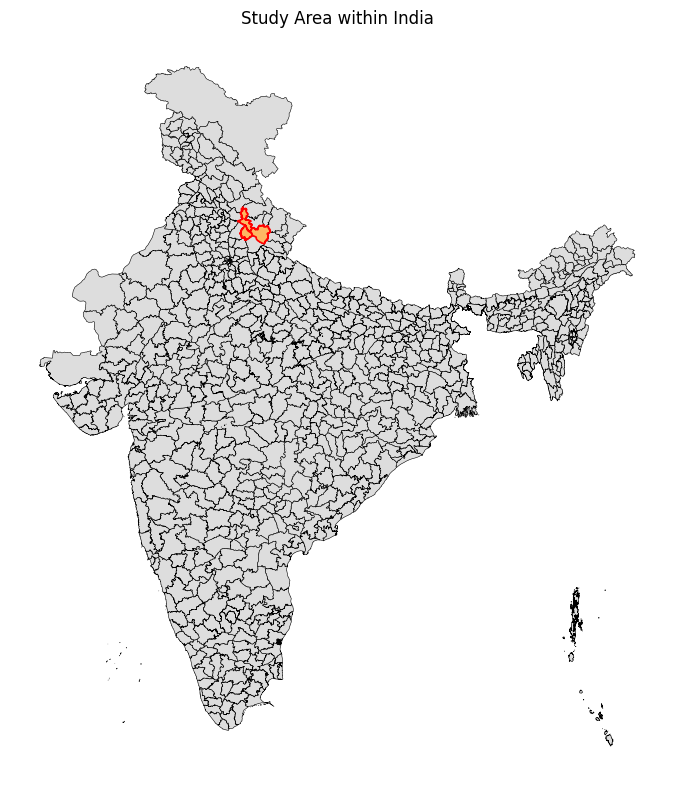

In [13]:
india = load_district_boundary()

fig, ax = plot_india_context(
    india,
    study_districts,
)

save_figure(
    fig,
    STATIC_MAPS / "01_india_context.png",
)

plt.show()

Saved /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/maps/static/02_study_area.png


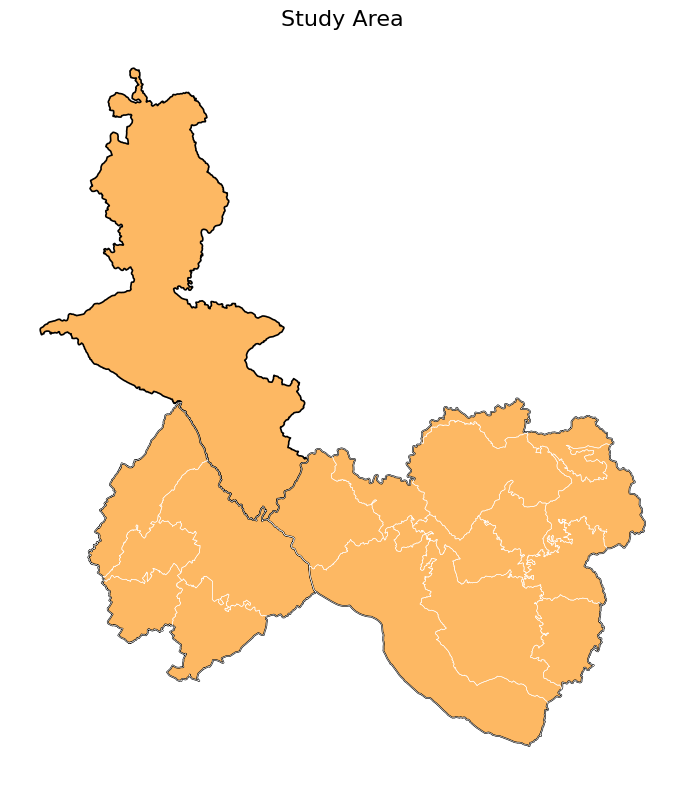

In [14]:
fig, ax = plot_boundaries(
    study_districts,
    study_taluks,
    title="Study Area",
)

save_figure(
    fig,
    STATIC_MAPS / "02_study_area.png",
)

plt.show()

In [ ]:
export_geopackage(
    study_districts,
    PROCESSED / "study_districts.gpkg",
)

export_geopackage(
    study_taluks,
    PROCESSED / "study_taluks.gpkg",
)

In [10]:
inventory = pd.DataFrame(inventory)
inventory

,Year,Scene,Bands
0,2016,Scene1,4
1,2016,Scene2,4
2,2016,Scene3,4
3,2022,Scene1,4
4,2022,Scene2,4
5,2022,Scene3,4
6,2025,Scene1,4
7,2025,Scene2,4
8,2025,Scene3,4


In [12]:
inventory.to_csv(
    REPORT /
    "tables" /
    "satellite_inventory.csv",
    index=False
)

In [13]:
metadata_rows = []

for year in years:
    scenes = list_scenes(year)

    for scene in scenes:
        band_files = list_band_files(scene)

        for band in band_files:

            with open_raster(band) as src:
                meta = get_raster_metadata(src)

                metadata_rows.append({
                    "Year": year,
                    "Scene": scene.name,
                    "Band": band.name,
                    "Width": meta["Width"],
                    "Height": meta["Height"],
                    "CRS": meta["CRS"],
                    "Resolution": meta["Resolution"],
                    "DataType": meta["Data Type"]
                })

In [14]:
raster_inventory = pd.DataFrame(metadata_rows)
raster_inventory

,Year,Scene,Band,Width,Height,CRS,Resolution,DataType
0,2016,Scene1,BAND2.tif,8080,7232,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"
1,2016,Scene1,BAND3.tif,8080,7232,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"
2,2016,Scene1,BAND4.tif,8080,7232,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"
3,2016,Scene1,BAND5.tif,8080,7232,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"
4,2016,Scene2,BAND2.tif,7666,7452,"PROJCS[""WGS 84 / UTM zone 43N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"
5,2016,Scene2,BAND3.tif,7666,7452,"PROJCS[""WGS 84 / UTM zone 43N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"
6,2016,Scene2,BAND4.tif,7666,7452,"PROJCS[""WGS 84 / UTM zone 43N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"
7,2016,Scene2,BAND5.tif,7666,7452,"PROJCS[""WGS 84 / UTM zone 43N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"
8,2016,Scene3,BAND2.tif,7965,7118,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"
9,2016,Scene3,BAND3.tif,7965,7118,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)","(uint16,)"


In [21]:
raster_inventory.to_csv(
    REPORT /
    "tables" /
    "raster_inventory.csv",
    index=False
)

In [16]:
health_files = list_files(HEALTH)

for file in health_files:
    print(file.name)

.DS_Store
2015-2016
.DS_Store
Dehradun-Dec.xls
Haridwar-Dec.xls
PauriGarhwal-Dec.xls
2020-2021
.DS_Store
Dehradun-Dec.xlsx
Haridwar-Dec.xlsx
PauriGarhwal-Dec.xlsx
2021-22
Dehradun-May.xlsx
Haridwar-May.xlsx
PauriGarhwal-May.xlsx


In [19]:
census_files = list_files(CENSUS)
for file in census_files:
    print(file.name)

PCA_11_DDN.xlsx
PCA_11_GHW.xlsx
PCA_11_HDW.xlsx


In [17]:
animal_files = list_files(LIVESTOCK)
animal_files

[PosixPath('/Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/data/raw/livestock/Animal_Husbandry_2024.pdf')]

In [20]:
print_header("Dataset Audit Completed")
print()
print(f"Study Districts : {len(study_area)}")
print(f"Satellite Years : {len(years)}")
print(f"Satellite Scenes : {len(inventory)}")
print(f"HMIS Files : {len(health_files)}")
print(f"Census Files : {len(census_files)}")

Dataset Audit Completed

Study Districts : 3
Satellite Years : 3
Satellite Scenes : 9
HMIS Files : 15
Census Files : 3
